# RW Model Fit to Beta Power

Grid-search least-squares fit of Rescorla–Wagner model to trial-wise Beta power.
Free parameters: learning rate **α** and bias **ε**.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

SUBJECT = '01'
SESSION = '01'
TASK    = 'Cannonball MF'

PROJECT_ROOT    = Path('..').resolve()
DERIVATIVES_DIR = PROJECT_ROOT / 'data' / 'derivatives' / 'mne_preproc'
sub_ses_dir     = DERIVATIVES_DIR / f'sub-{SUBJECT}' / f'ses-{SESSION}'
prefix          = f'sub-{SUBJECT}_ses-{SESSION}_task-{TASK}'
EPOCHS_PATH     = sub_ses_dir / f'{prefix}_epochs_feedback_clean-epo.fif'

BAND           = (13., 30.)
ROI_CANDIDATES = ['C3','Cz','C4','CP3','CP4','FC3','FC4']
ANTICI_TMIN    = -0.5
ANTICI_TMAX    =  0.0
EDGE_CROP      =  0.05
ALPHA_GRID     = np.linspace(0.01, 0.99, 99)

epochs = mne.read_epochs(str(EPOCHS_PATH), preload=True, verbose=False)
print(f'Loaded {len(epochs)} epochs  |  tmin={epochs.tmin:.3f} s')

Loaded 713 epochs  |  tmin=-0.699 s


In [3]:
# Derive outcomes directly from epoch event codes — no file alignment needed
# 19 = reward (asteroidTail), 17 = loss (ballExplode)
outcomes = (epochs.events[:, 2] == 19).astype(float)
print(f'Outcomes: {int(outcomes.sum())} reward, {int((1-outcomes).sum())} loss  | n={len(outcomes)}')

Outcomes: 453 reward, 260 loss  | n=713


## Extract Band Power

In [4]:
eeg_names = set(epochs.ch_names)
roi = [ch for ch in ["C3","Cz","C4","CP3","CP4","FC3","FC4"] if ch in eeg_names]
assert len(roi) > 0, f'No ROI channels found. Available: {epochs.ch_names[:10]}'
print(f'Beta (sensorimotor) ROI: {roi}')

inner_tmin = ANTICI_TMIN + EDGE_CROP
inner_tmax = ANTICI_TMAX - EDGE_CROP

env = (
    epochs.copy()
    .pick(roi)
    .filter(l_freq=BAND[0], h_freq=BAND[1], verbose=False)
    .apply_hilbert(envelope=True)
    .crop(tmin=inner_tmin, tmax=inner_tmax)
)
power = (env.get_data() ** 2).mean(axis=(1, 2))
print(f'Power shape: {power.shape}  mean={power.mean():.3e}')

Beta (sensorimotor) ROI: ['C3', 'Cz', 'C4', 'CP3', 'CP4', 'FC3', 'FC4']
Power shape: (713,)  mean=4.411e-12


## Grid-Search RW Fit

In [5]:
def simulate_rw(outcomes, alpha, V0=0.5):
    V = np.zeros(len(outcomes))
    v = V0
    for i, r in enumerate(outcomes):
        V[i] = v
        v = v + alpha * (r - v)
    return V

# Log-transform power (reduces skew, standard for oscillatory power)
log_power     = np.log(power + 1e-30)
power_z_all   = (log_power - log_power.mean()) / log_power.std()
keep          = np.abs(power_z_all) <= 3
log_power_filt = log_power[keep]
print(f'Trials kept: {keep.sum()} / {len(keep)} (removed {(~keep).sum()})')

# Maximise |r| — alpha power DECREASES with higher V(t) (desynchronisation)
best_absr, best_r, best_alpha, best_V = -np.inf, None, None, None
r_curve = np.zeros(len(ALPHA_GRID))

for j, alpha in enumerate(ALPHA_GRID):
    V_full = simulate_rw(outcomes, alpha)
    V_filt = V_full[keep]
    r, _ = pearsonr(V_filt, log_power_filt)
    r_curve[j] = r
    if abs(r) > best_absr:
        best_absr, best_r, best_alpha, best_V = abs(r), r, alpha, V_filt

power_clean = log_power_filt
_, best_p = pearsonr(best_V, power_clean)

print(f'Best alpha : {best_alpha:.3f}')
print(f'Pearson r  : {best_r:.3f},  p = {best_p:.4f}')
print(f'Direction  : {"higher V → lower power (desync)" if best_r < 0 else "higher V → higher power"}')

Trials kept: 708 / 713 (removed 5)
Best alpha : 0.990
Pearson r  : 0.065,  p = 0.0858
Direction  : higher V → higher power


## Plot

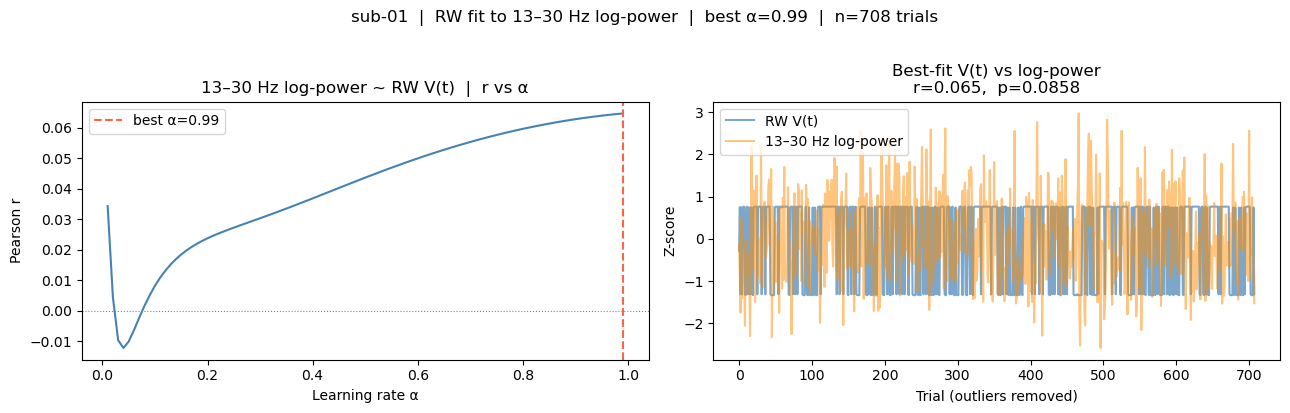

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ALPHA_GRID, r_curve, color='steelblue')
axes[0].axvline(best_alpha, color='tomato', linestyle='--',
                label=f'best α={best_alpha:.2f}')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Learning rate α')
axes[0].set_ylabel('Pearson r')
axes[0].set_title(f'{BAND[0]:.0f}–{BAND[1]:.0f} Hz log-power ~ RW V(t)  |  r vs α')
axes[0].legend()

pwr_z = (power_clean - power_clean.mean()) / power_clean.std()
V_z   = (best_V     - best_V.mean())      / best_V.std()
axes[1].plot(V_z,   alpha=0.7, color='steelblue',    label='RW V(t)')
axes[1].plot(pwr_z, alpha=0.5, color='darkorange',   label=f'{BAND[0]:.0f}–{BAND[1]:.0f} Hz log-power')
axes[1].set_xlabel('Trial (outliers removed)')
axes[1].set_ylabel('Z-score')
axes[1].set_title(f'Best-fit V(t) vs log-power\nr={best_r:.3f},  p={best_p:.4f}')
axes[1].legend()

fig.suptitle(
    f'sub-{SUBJECT}  |  RW fit to {BAND[0]:.0f}–{BAND[1]:.0f} Hz log-power  '
    f'|  best α={best_alpha:.2f}  |  n={keep.sum()} trials',
    y=1.02
)
plt.tight_layout()
plt.show()

In [7]:
# Save RW-beta results for between-subjects averaging
from pathlib import Path
_sub_ses_dir = Path('..').resolve() / 'data' / 'derivatives' / 'mne_preproc' / f'sub-{SUBJECT}' / f'ses-{SESSION}'
_prefix      = f'sub-{SUBJECT}_ses-{SESSION}_task-{TASK}'
rw_beta_path = _sub_ses_dir / f'{_prefix}_rw_beta_results.npz'

np.savez(
    str(rw_beta_path),
    subject    = SUBJECT,
    best_alpha = best_alpha,
    best_r     = best_r,
    best_p     = best_p,
    r_curve    = r_curve,
    alpha_grid = ALPHA_GRID,
)
print(f"Saved RW-beta results → {rw_beta_path}")

Saved RW-beta results → /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_rw_beta_results.npz
